# 🧠 Módulo 9: Redes Neurais

## Objetivos de Aprendizagem

Ao final deste módulo você será capaz de:

- Entender o modelo do **neurônio artificial** e sua analogia biológica
- Compreender e comparar diferentes **funções de ativação** (Sigmoid, Tanh, ReLU, Leaky ReLU, Softmax)
- Implementar um **Perceptron** do zero usando NumPy
- Construir e avaliar um **MLP (Multilayer Perceptron)** com scikit-learn
- Entender o algoritmo de **Backpropagation** e a regra da cadeia
- Interpretar **curvas de aprendizado** e identificar overfitting
- Compreender o conceito de **SOM (Self-Organizing Map)** para aprendizado não supervisionado

## Teoria Matemática

### Neurônio Artificial
$$z = \sum_{j=1}^n w_j x_j + b = \mathbf{w}^T \mathbf{x} + b, \quad \hat{y} = f(z)$$

### Funções de Ativação
$$\text{Sigmoid}(z) = \frac{1}{1+e^{-z}} \in (0,1)$$
$$\text{Tanh}(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} \in (-1,1)$$
$$\text{ReLU}(z) = \max(0, z)$$
$$\text{Leaky ReLU}(z) = \max(\alpha z, z), \quad \alpha \ll 1$$
$$\text{Softmax}(z_k) = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}$$

### Backpropagation (Regra da Cadeia)
$$\frac{\partial L}{\partial w_j^{(l)}} = \frac{\partial L}{\partial a^{(l+1)}} \cdot \frac{\partial a^{(l+1)}}{\partial z^{(l+1)}} \cdot \frac{\partial z^{(l+1)}}{\partial w_j^{(l)}}$$

### Gradient Descent
$$w_j \leftarrow w_j - \eta \frac{\partial L}{\partial w_j}$$

### Cross-Entropy Loss (Classificação)
$$L = -\sum_{i=1}^n \sum_{k=1}^K y_{ik} \log(\hat{y}_{ik})$$

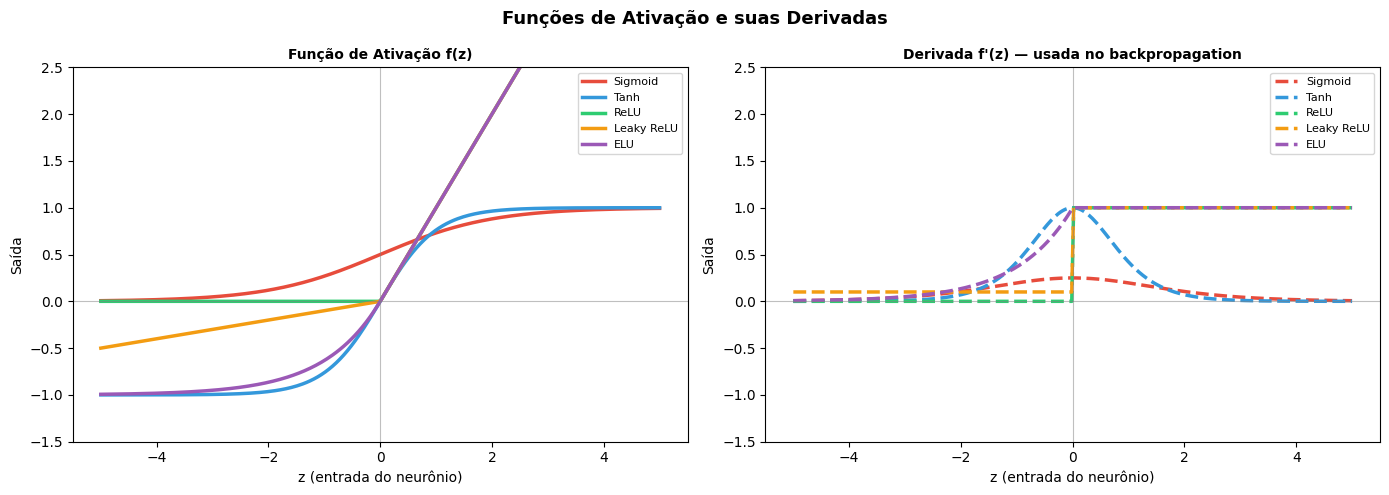

💡 ReLU é a mais usada em Deep Learning pois evita o 'vanishing gradient'
   Sigmoid e Tanh sofrem de gradientes muito pequenos para |z| grande


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Funções de ativação
z = np.linspace(-5, 5, 300)
funcs = {
    'Sigmoid': (1/(1+np.exp(-z)), lambda dz: (1/(1+np.exp(-dz)))*(1 - 1/(1+np.exp(-dz)))),
    'Tanh': (np.tanh(z), lambda dz: 1 - np.tanh(dz)**2),
    'ReLU': (np.maximum(0, z), lambda dz: (dz > 0).astype(float)),
    'Leaky ReLU': (np.where(z>0, z, 0.1*z), lambda dz: np.where(dz>0, 1.0, 0.1)),
    'ELU': (np.where(z>0, z, 1.0*(np.exp(z)-1)), lambda dz: np.where(dz>0, 1.0, np.exp(dz))),
}
cores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Funções de Ativação e suas Derivadas', fontsize=13, fontweight='bold')

for (nome, (func_val, func_der)), cor in zip(funcs.items(), cores):
    axes[0].plot(z, func_val, color=cor, lw=2.5, label=nome)
    axes[1].plot(z, func_der(z), color=cor, lw=2.5, label=nome, linestyle='--')

for ax, titulo in zip(axes, ['Função de Ativação f(z)', 'Derivada f\'(z) — usada no backpropagation']):
    ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, alpha=0.5)
    ax.set_xlabel('z (entrada do neurônio)'); ax.set_ylabel('Saída')
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8); ax.set_ylim(-1.5, 2.5)

plt.tight_layout()
plt.savefig('../imagens/09_funcoes_ativacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 ReLU é a mais usada em Deep Learning pois evita o 'vanishing gradient'")
print("   Sigmoid e Tanh sofrem de gradientes muito pequenos para |z| grande")

🔧 PERCEPTRON IMPLEMENTADO DO ZERO

Porta Lógica AND — Resultado:
  0 AND 0 = -1 | Predito: -1 ✅
  0 AND 1 = -1 | Predito: -1 ✅
  1 AND 0 = -1 | Predito: -1 ✅
  1 AND 1 = +1 | Predito: +1 ✅


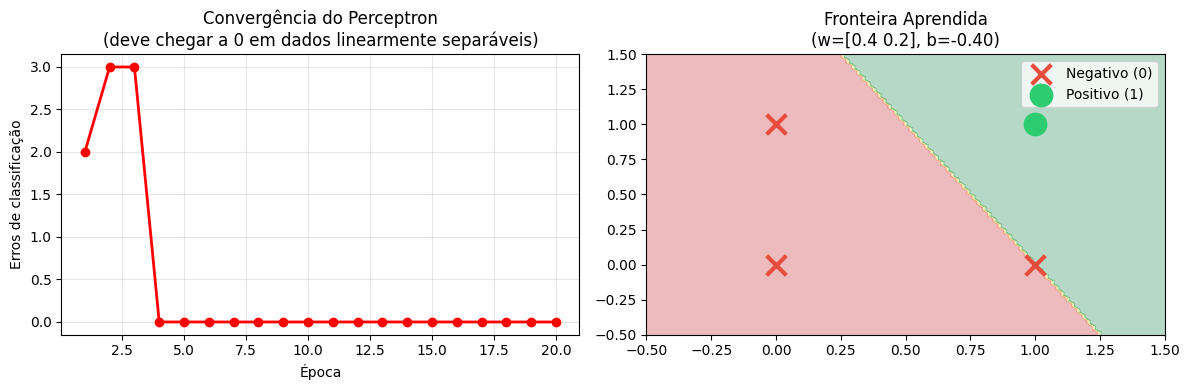

In [2]:
print("=" * 55)
print("🔧 PERCEPTRON IMPLEMENTADO DO ZERO")
print("=" * 55)

class Perceptron:
    def __init__(self, taxa_aprendizado=0.01, n_epocas=100):
        self.eta = taxa_aprendizado
        self.n_epocas = n_epocas
    
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.erros = []
        
        for _ in range(self.n_epocas):
            erros_epoca = 0
            for xi, yi in zip(X, y):
                pred = self.predict_single(xi)
                update = self.eta * (yi - pred)
                self.w += update * xi
                self.b += update
                erros_epoca += int(update != 0)
            self.erros.append(erros_epoca)
        return self
    
    def predict_single(self, x):
        return 1 if (np.dot(x, self.w) + self.b) >= 0 else -1
    
    def predict(self, X):
        return np.array([self.predict_single(xi) for xi in X])

# Dataset: Porta Lógica AND
X_and = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_and = np.array([-1,-1,-1,1])  # AND: só [1,1] é positivo

p = Perceptron(taxa_aprendizado=0.1, n_epocas=20)
p.fit(X_and, y_and)
print("\nPorta Lógica AND — Resultado:")
for x, y_real in zip(X_and, y_and):
    pred = p.predict_single(x)
    print(f"  {x[0]:.0f} AND {x[1]:.0f} = {y_real:+d} | Predito: {pred:+d} {'✅' if pred == y_real else '❌'}")

# Convergência
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(p.erros)+1), p.erros, 'r-o', lw=2, ms=6)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Erros de classificação')
axes[0].set_title('Convergência do Perceptron\n(deve chegar a 0 em dados linearmente separáveis)')
axes[0].grid(True, alpha=0.3)

# Visualização da fronteira aprendida
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
Z = np.array([p.predict_single(np.array([x, y])) for x, y in zip(xx.ravel(), yy.ravel())])
Z = Z.reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
axes[1].scatter(X_and[y_and==-1, 0], X_and[y_and==-1, 1], c='#e74c3c', s=200, 
                 marker='x', lw=3, label='Negativo (0)')
axes[1].scatter(X_and[y_and==1, 0], X_and[y_and==1, 1], c='#2ecc71', s=200, 
                 marker='o', lw=3, label='Positivo (1)')
axes[1].set_title(f'Fronteira Aprendida\n(w={p.w.round(2)}, b={p.b:.2f})')
axes[1].legend(); axes[1].set_xlim(-0.5, 1.5); axes[1].set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.savefig('../imagens/09_perceptron.png', dpi=150, bbox_inches='tight')
plt.show()

🧠 MLP (MULTILAYER PERCEPTRON) COM SCIKIT-LEARN


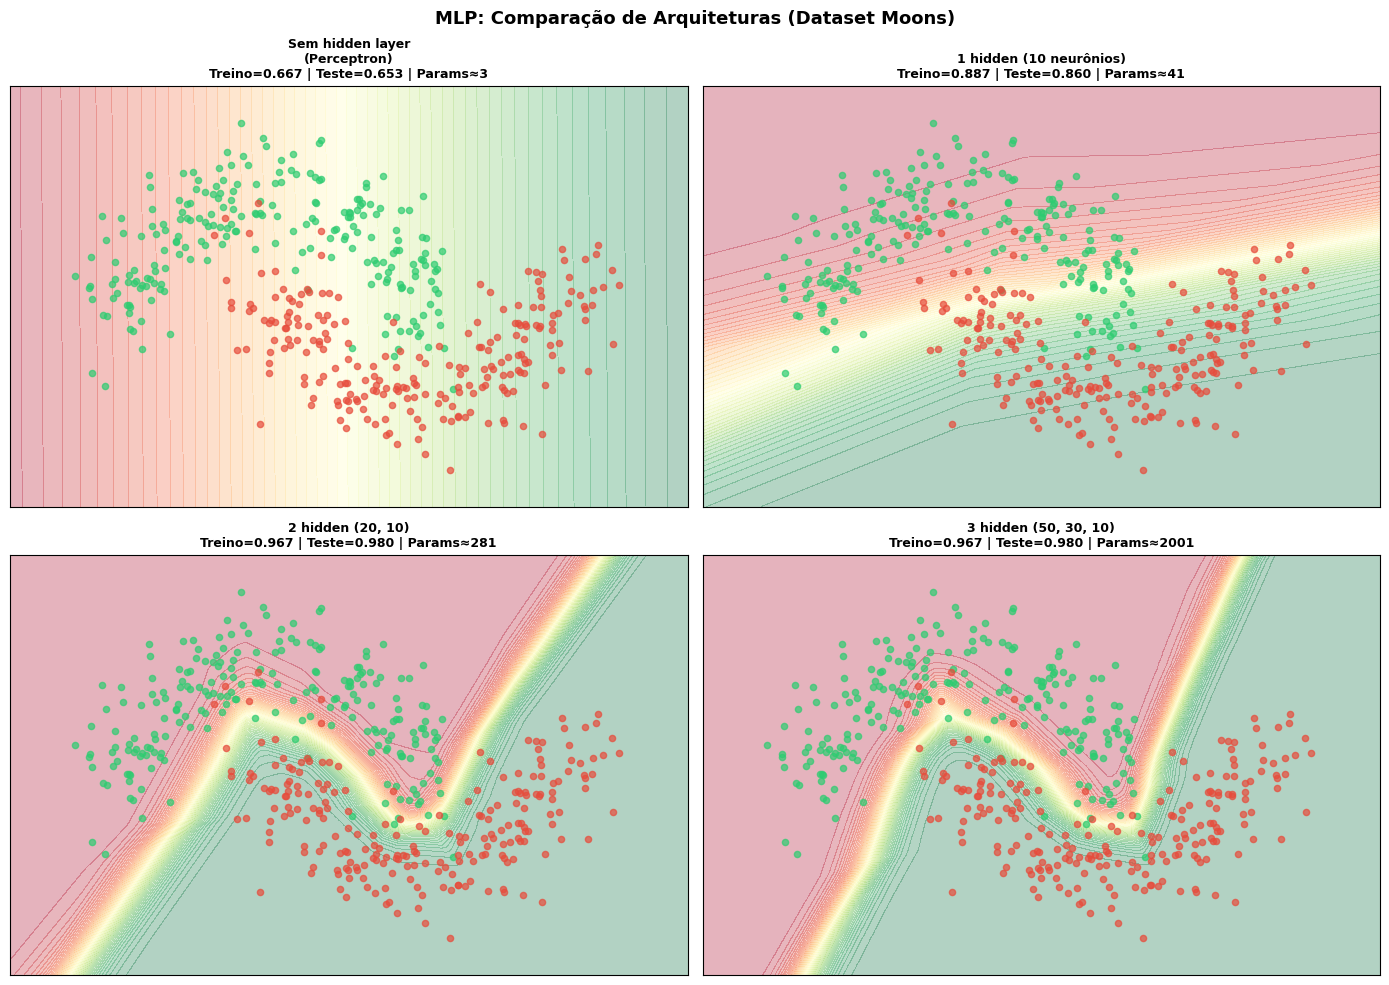

In [3]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from sklearn.metrics import classification_report

print("=" * 55)
print("🧠 MLP (MULTILAYER PERCEPTRON) COM SCIKIT-LEARN")
print("=" * 55)

# XOR problem (não-linearmente separável — requer hidden layers)
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

# Dataset mais complexo: moons
X_moon, y_moon = make_moons(n_samples=600, noise=0.2, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_moon, y_moon, test_size=0.25, random_state=42)

# Comparar arquiteturas
arquiteturas = {
    'Sem hidden layer\n(Perceptron)': ((),),
    '1 hidden (10 neurônios)': ((10,),),
    '2 hidden (20, 10)': ((20, 10),),
    '3 hidden (50, 30, 10)': ((50, 30, 10),),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MLP: Comparação de Arquiteturas (Dataset Moons)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, (titulo, (hidden,)) in zip(axes, arquiteturas.items()):
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_train_m)
    X_te_sc = sc.transform(X_test_m)
    
    mlp = MLPClassifier(hidden_layer_sizes=hidden, max_iter=500, random_state=42,
                         activation='relu', solver='adam')
    mlp.fit(X_tr_sc, y_train_m)
    acc_treino = mlp.score(X_tr_sc, y_train_m)
    acc_teste = mlp.score(X_te_sc, y_test_m)
    
    # Fronteira de decisão
    X_all_sc = sc.transform(X_moon)
    xx_range = np.linspace(X_all_sc[:,0].min()-0.5, X_all_sc[:,0].max()+0.5, 150)
    yy_range = np.linspace(X_all_sc[:,1].min()-0.5, X_all_sc[:,1].max()+0.5, 150)
    xx, yy = np.meshgrid(xx_range, yy_range)
    Z = mlp.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn', levels=50)
    ax.scatter(X_tr_sc[y_train_m==0, 0], X_tr_sc[y_train_m==0, 1], c='#2ecc71', s=20, alpha=0.7)
    ax.scatter(X_tr_sc[y_train_m==1, 0], X_tr_sc[y_train_m==1, 1], c='#e74c3c', s=20, alpha=0.7)
    
    n_params = sum(p.size for p in [mlp.coefs_[0]] + mlp.coefs_[1:] + mlp.intercepts_)
    ax.set_title(f'{titulo}\nTreino={acc_treino:.3f} | Teste={acc_teste:.3f} | Params≈{n_params}',
                  fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('../imagens/09_mlp_arquiteturas.png', dpi=150, bbox_inches='tight')
plt.show()

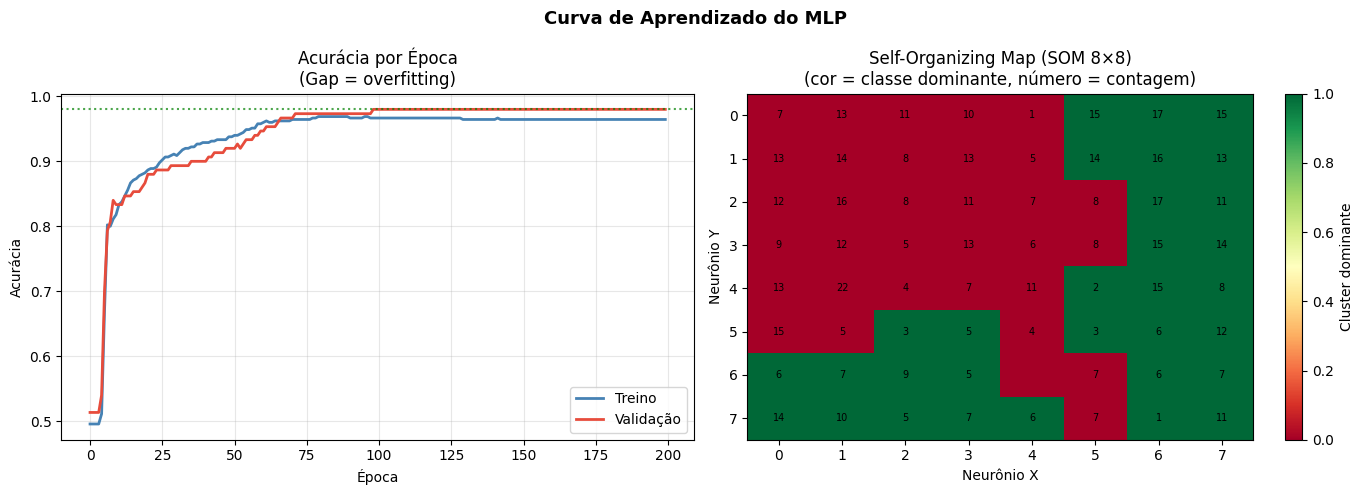

In [4]:
# Curva de aprendizado
mlp_deep = MLPClassifier(hidden_layer_sizes=(50, 30, 10), max_iter=1, warm_start=True, 
                           random_state=42, activation='relu')
sc = StandardScaler()
X_all_sc = sc.fit_transform(X_moon)
X_tr_sc = sc.transform(X_train_m)
X_te_sc = sc.transform(X_test_m)

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(200):
    mlp_deep.fit(X_tr_sc, y_train_m)
    train_accs.append(mlp_deep.score(X_tr_sc, y_train_m))
    test_accs.append(mlp_deep.score(X_te_sc, y_test_m))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curva de Aprendizado do MLP', fontsize=13, fontweight='bold')

axes[0].plot(train_accs, color='steelblue', lw=2, label='Treino')
axes[0].plot(test_accs, color='#e74c3c', lw=2, label='Validação')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Acurácia')
axes[0].set_title('Acurácia por Época\n(Gap = overfitting)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axhline(max(test_accs), color='green', lw=1.5, linestyle=':', alpha=0.7,
                  label=f'Melhor: {max(test_accs):.3f}')

# SOM (Self-Organizing Map) com minisom
try:
    from minisom import MiniSom
    
    som = MiniSom(x=8, y=8, input_len=2, sigma=1.0, learning_rate=0.5, random_seed=42)
    som.train_random(X_all_sc, 1000, verbose=False)
    
    win_map = np.zeros((8, 8, 3))
    win_count = np.zeros((8, 8))
    for x, label in zip(X_all_sc, y_moon):
        bmu = som.winner(x)
        win_map[bmu[0], bmu[1], label] += 1
        win_count[bmu[0], bmu[1]] += 1
    
    cluster_som = np.argmax(win_map[:,:,:2], axis=2)
    im = axes[1].imshow(cluster_som, cmap='RdYlGn', aspect='auto', interpolation='nearest')
    
    for i in range(8):
        for j in range(8):
            if win_count[i,j] > 0:
                axes[1].text(j, i, str(int(win_count[i,j])), ha='center', va='center', 
                              fontsize=7, color='black')
    
    plt.colorbar(im, ax=axes[1], label='Cluster dominante')
    axes[1].set_title('Self-Organizing Map (SOM 8×8)\n(cor = classe dominante, número = contagem)')
    axes[1].set_xlabel('Neurônio X'); axes[1].set_ylabel('Neurônio Y')
    
except ImportError:
    axes[1].text(0.5, 0.5, 'MiniSom não instalado\npip install minisom', 
                  transform=axes[1].transAxes, ha='center', va='center', fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('../imagens/09_aprendizado_som.png', dpi=150, bbox_inches='tight')
plt.show()

## Resumo e Comparação

| Modelo | Camadas | Parâmetros | Fronteira | Quando Usar |
|--------|---------|------------|-----------|-------------|
| **Perceptron** | 1 (entrada + saída) | Poucos | Linear apenas | Dados linearmente separáveis, baseline |
| **MLP** | 2+ (entrada + hidden + saída) | Médio | Não-linear | Classificação/Regressão geral, tabular |
| **Deep Learning** | Muitas (10-1000+) | Milhões | Altamente complexa | Imagens, texto, áudio, séries temporais |
| **SOM** | 2 (entrada + grade 2D) | Grade × features | Topológica | Visualização, clustering, anomalias |

### Pontos-Chave

- **Vanishing Gradient**: Sigmoid e Tanh têm derivadas muito pequenas para |z| grande — gradientes somem nas camadas iniciais
- **ReLU** resolve o vanishing gradient, mas pode sofrer de "neurônios mortos" (sempre zero)
- **Backpropagation** usa a regra da cadeia para calcular gradientes de forma eficiente
- **Normalização** dos dados é essencial para redes neurais (StandardScaler)
- **Adam** é geralmente o melhor otimizador para começar (adaptativo)

## Exercícios Propostos

1. **Implemente uma MLP do zero** (sem sklearn) com uma hidden layer, usando numpy. Teste no dataset Moons.
2. **Compare ativações**: treine 5 MLPs idênticas com ativações diferentes (sigmoid, tanh, relu, elu, selu). Qual converge mais rápido?
3. **Experimente com o dataset Iris**: use MLP para classificação multiclasse (3 classes) e plote a matriz de confusão.
4. **Regularização**: adicione `alpha` (L2) ao MLPClassifier e observe como muda o overfitting na curva de aprendizado.
5. **SOM avançado**: treine um SOM no dataset Iris (4 features) e visualize quais regiões do mapa correspondem a cada espécie.